# Hawkes-process JSCC — code temporel appris sur une source à rafales

Suite de `point_process_jscc.ipynb`, même énoncé (`student_project_point_process_jscc.pdf`),
même canal à jitter gaussien, même contrainte `N_X = N_S`, `R = 1`. Deux choses changent :

1. **La source** : un processus de Hawkes à noyau exponentiel plutôt que Poisson/renouvellement.
   Contrairement à Poisson (i.i.d.) ou au renouvellement Gamma (mémoire d'un seul intervalle),
   Hawkes a une mémoire qui s'étend sur plusieurs événements passés — c'est la source la plus
   riche en structure exploitable des trois, et celle qui teste le plus directement la question
   de recherche du PDF : *le JSCC appris découvre-t-il qu'il faut représenter la géométrie
   temporelle relative entre événements, pas seulement les temps individuels ?*
2. **L'architecture** : `point_process_jscc.ipynb` utilise un MLP (`nn.Linear` + `GELU`) pour
   l'encodeur et le décodeur — un ANN, pas un SNN, ce qui ne respecte pas la consigne de
   `task_1.pdf` ("SNN-based encoder... SNN-based decoder"). Ici, l'encodeur et le décodeur sont
   de vrais réseaux de neurones à impulsions (LIF, seuil, spikes binaires, surrogate gradient) —
   volontairement **simples** : une seule couche cachée feed-forward, sans connexion récurrente
   apprise (voir plus bas pourquoi).

## Deux bugs trouvés en cours de route, corrigés en dur dans la conception

**Le réordonnancement.** Un encodeur qui apprend un déplacement additif indépendant par
événement (`X_i = T_i + delta_i`, ce que fait `point_process_jscc.ipynb`) peut, si `delta` est
assez grand, faire *croiser* deux événements voisins — un problème d'autant plus sévère que les
gaps sont petits, donc exactement ce que produit une rafale Hawkes. Vérifié : reproduit à
l'identique avec le MLP original *et* avec ce SNN (15 à 35 % des paires d'événements inversées
dès les 50 premiers pas de gradient, perte finale 10 à 100x pire qu'un système non codé). Ce
n'est pas un défaut d'architecture, c'est un défaut de paramétrage. La correction : l'encodeur
apprend un **facteur multiplicatif positif par écart** (`g_i^{(X)} = g_i \cdot m_i`, `m_i > 0`),
exactement l'objet de l'éq. 12 du PDF, puis `X = cumsum(g^{(X)})` — l'ordre ne peut alors
structurellement jamais s'inverser, quel que soit l'entraînement.

**La queue de la source.** Un bloc de Hawkes simulé par accumulation d'écarts n'est pas borné à
`Ts` par construction : dans certains tirages (vérifié : 33 % même pour `branching = 0`, i.e.
Poisson pur simulé de cette façon), le dernier des `n_events` événements tombe bien après `Ts`.
`point_process_jscc.ipynb` évite le problème pour Poisson en tirant directement `n_events` points
uniformes dans `[0, Ts]` (statistiques d'ordre) — une astuce qui ne s'applique pas à un processus
à mémoire. Ici, chaque bloc simulé est renormalisé pour que son dernier événement tombe
exactement sur `Ts` : un simple changement d'échelle affine, qui laisse la géométrie temporelle
*relative* intacte (rafales, silences) — précisément ce que l'encodeur doit apprendre à exploiter —
tout en garantissant que la source tient dans la fenêtre du bloc.

In [1]:
from __future__ import annotations  # `X | None` en annotation, aussi sous Python 3.9

from dataclasses import dataclass, replace
import time

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.set_num_threads(4)
DEVICE = "cpu"


@dataclass
class Config:
    # ---------------- source (Hawkes) ---------------------------------------
    n_events: int = 8           # N, événements par bloc, fixé.
    Ts: float = 1.0             # durée du bloc source. Tc = Ts puisque R = 1.
    hawkes_branching: float = 0.5   # n = alpha/beta dans (0,1) : part du taux
                                     # qui vient de l'auto-excitation. n->0 :
                                     # quasi-Poisson. n->1 : rafales instables.
    hawkes_decay: float = 1.0       # durée de vie de l'excitation, unités de
                                     # gap moyen.

    # ---------------- canal ---------------------------------------------------
    sigma_J: float = 0.03       # écart-type du jitter (unités de Ts).
    sort_output: bool = True    # le décodeur reçoit l'ensemble trié.

    # ---------------- encodeur (facteur multiplicatif, cf. markdown ci-dessus)
    log_max_stretch: float = 0.5    # g_i^X = g_i * exp(log_max_stretch * tanh(.))
                                     # borne le facteur à [e^-0.5, e^0.5] ~ [0.6, 1.65]
    window: str = "clamp"           # confine X à [0, Tc], ce que le PDF impose.

    # ---------------- décodeur --------------------------------------------------
    max_corr: float = 2.0       # s_hat = y + mean_gap*max_corr*tanh(raw)

    # ---------------- réseau (SNN) ----------------------------------------------
    hidden: int = 64            # largeur de l'unique couche cachée LIF.

    # ---------------- optimisation ------------------------------------------------
    steps: int = 3000
    batch: int = 256
    lr: float = 3e-3
    seed: int = 0
    eval_batch: int = 8000

    @property
    def Tc(self) -> float:
        return self.Ts                      # R = Ts/Tc = 1

    @property
    def mean_gap(self) -> float:
        return self.Ts / (self.n_events + 1)


CFG = Config()
print(CFG)
print(f"mean_gap = {CFG.mean_gap:.4f}")

Config(n_events=8, Ts=1.0, hawkes_branching=0.5, hawkes_decay=1.0, sigma_J=0.03, sort_output=True, log_max_stretch=0.5, window='clamp', max_corr=2.0, hidden=64, steps=3000, batch=256, lr=0.003, seed=0, eval_batch=8000)
mean_gap = 0.1111


## Constantes d'exécution

In [2]:
BRANCHING_GRID = [0.0, 0.3, 0.6, 0.85]   # 0.0 = quasi-Poisson, contrôle sans mémoire
SIGMA_RATIO = 0.4                         # sigma_J / mean_gap, fixe pour tout le sweep
MODES = ["uncoded", "decoder", "jscc"]

RASTER_N_BLOCKS, RASTER_SEED = 16, 3
GAPMAP_N_BLOCKS, GAPMAP_SEED = 4000, 4242
REALISATION_BLOCK, REALISATION_SEED = 0, 7

## Conventions de tracé

Même palette et même fonction `style` que `point_process_jscc.ipynb` (elle-même alignée sur
`temporal-jscc/scripts/visualize.py`), pour que les trois notebooks se lisent ensemble.

In [3]:
C_UNCODED, C_DECODER, C_JSCC = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK2, MUTED, GRID, SURFACE = "#0b0b0b", "#52514e", "#8a8983", "#e4e3df", "#fcfcfb"
MODE_STYLE = {"uncoded": (C_UNCODED, "o"), "decoder": (C_DECODER, "s"),
              "jscc": (C_JSCC, "^")}


def style(ax, xlabel, ylabel, title, subtitle=None):
    ax.set_facecolor(SURFACE)
    ax.grid(True, color=GRID, lw=0.8, zorder=0)
    ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color(GRID)
    ax.tick_params(colors=INK2, labelsize=9, length=3, color=GRID)
    ax.set_xlabel(xlabel, color=INK2, fontsize=10)
    ax.set_ylabel(ylabel, color=INK2, fontsize=10)
    ax.set_title(title, color=INK, fontsize=12, loc="left", pad=26 if subtitle else 8)
    if subtitle:
        ax.text(0.0, 1.02, subtitle, transform=ax.transAxes, color=MUTED,
                fontsize=9, va="bottom")


def legend(ax, loc="upper left"):
    leg = ax.legend(frameon=False, fontsize=9, loc=loc)
    for t in leg.get_texts():
        t.set_color(INK2)

## Source : Hawkes à noyau exponentiel

```
lambda(t) = mu + alpha * sum_{T_i < t} exp(-beta * (t - T_i))
```

chaque événement augmente temporairement l'intensité, donc les points arrivent en rafales
suivies de silences. `mu`, `alpha`, `beta` sont dérivés de `mean_gap`, `hawkes_branching`
(`n = alpha/beta`) et `hawkes_decay`, pour que le taux moyen à l'équilibre reste `1/mean_gap`.
Simulé exactement par amincissement de Ogata (1981), avec un rodage pour démarrer en régime
stationnaire.

**Renormalisation** (cf. l'intro) : le bloc brut est mis à l'échelle pour que son dernier
événement tombe sur `Ts` — un changement de temps affine, donc les rapports entre écarts
consécutifs sont inchangés.

In [4]:
def _hawkes_burn_and_record(mu, alpha, beta, n_burn, n_events, rng):
    """Un bloc de Hawkes, par amincissement de Ogata (1981). `n_burn` événements
    sont simulés et jetés avant d'enregistrer quoi que ce soit, pour démarrer
    en régime stationnaire plutôt qu'avec `excess = 0`."""
    t, excess = 0.0, 0.0
    for _ in range(n_burn):
        M = mu + excess
        tau = rng.exponential(1.0 / M)
        excess *= np.exp(-beta * tau)
        t += tau
        if rng.random() <= (mu + excess) / M:
            excess += alpha
    t0 = t

    times = []
    while len(times) < n_events:
        M = mu + excess
        tau = rng.exponential(1.0 / M)
        excess *= np.exp(-beta * tau)
        t += tau
        if rng.random() <= (mu + excess) / M:
            times.append(t - t0)
            excess += alpha
    return np.array(times[:n_events])


def sample_source(cfg: Config, batch: int, rng: np.random.Generator) -> torch.Tensor:
    """-> (batch, N) temps triés croissants, chaque bloc renormalisé sur [0, Ts].

    La récursion n'a aucune notion de fenêtre de bloc : elle émet des événements
    au rythme que dicte l'auto-excitation, donc le N-ième événement peut tomber
    bien après Ts (vérifié : ~33% des blocs même à branching = 0). Renormaliser
    chaque bloc par son propre dernier événement est le changement de temps qui
    laisse la géométrie relative des écarts intacte tout en garantissant que la
    source tient dans "un bloc observé sur une durée Ts", comme l'exige le PDF.
    """
    lam0 = 1.0 / cfg.mean_gap
    n = float(cfg.hawkes_branching)
    beta = 1.0 / (cfg.hawkes_decay * cfg.mean_gap)
    alpha = n * beta
    mu = lam0 * (1.0 - n)
    raw = np.stack([_hawkes_burn_and_record(mu, alpha, beta, 100, cfg.n_events, rng)
                    for _ in range(batch)])
    t = torch.tensor(raw, dtype=torch.float32, device=DEVICE)
    return t * (cfg.Ts / t[:, -1:])


def source_stats(cfg: Config, batch: int = 40000, seed: int = 12345) -> dict:
    t = sample_source(cfg, batch, np.random.default_rng(seed))
    g = torch.diff(t, dim=1, prepend=torch.zeros_like(t[:, :1]))
    return {"mean_gap": float(g.mean()), "cv_gap": float(g.std() / g.mean()),
            "frac_beyond_Ts": float((t[:, -1] > cfg.Ts + 1e-4).float().mean())}


for b in BRANCHING_GRID:
    print(f"branching={b:4.2f}  {source_stats(replace(CFG, hawkes_branching=b))}")

branching=0.00  {'mean_gap': 0.125, 'cv_gap': 0.8828828930854797, 'frac_beyond_Ts': 0.0}


branching=0.30  {'mean_gap': 0.125, 'cv_gap': 0.977898120880127, 'frac_beyond_Ts': 0.0}


branching=0.60  {'mean_gap': 0.125, 'cv_gap': 1.082687258720398, 'frac_beyond_Ts': 0.0}


branching=0.85  {'mean_gap': 0.125, 'cv_gap': 1.1817247867584229, 'frac_beyond_Ts': 0.0}


`frac_beyond_Ts` est à 0 pour toutes les valeurs de `branching` : la renormalisation fait son
travail. `cv_gap` (coefficient de variation des écarts) croît avec `branching` — c'est la
signature des rafales : plus de petits écarts (intra-rafale) et de grands écarts (silences
inter-rafales) qu'un renouvellement à variance comparable.

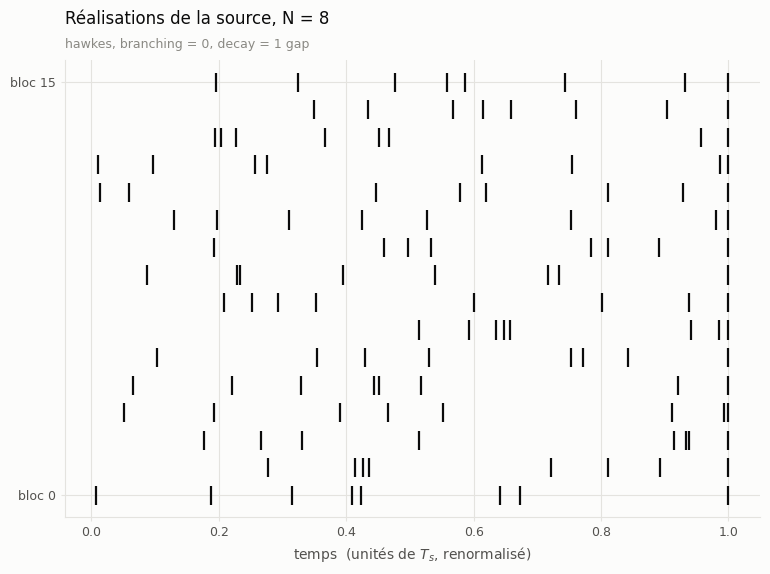

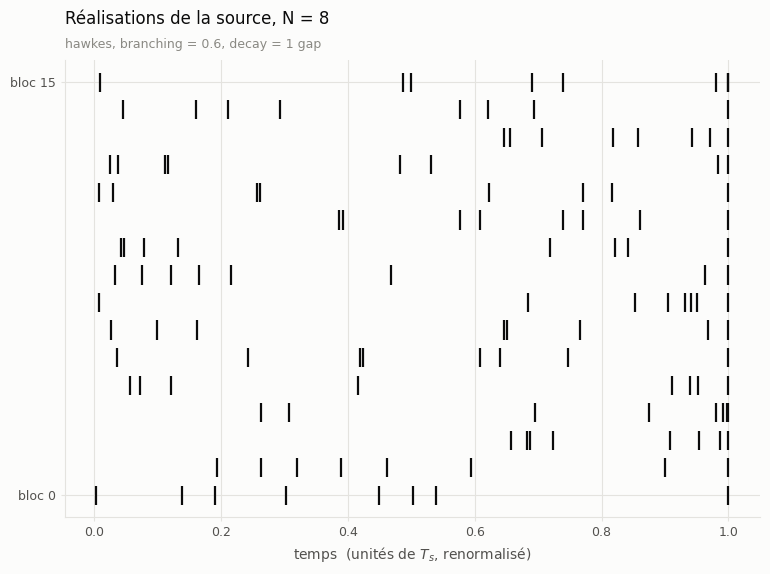

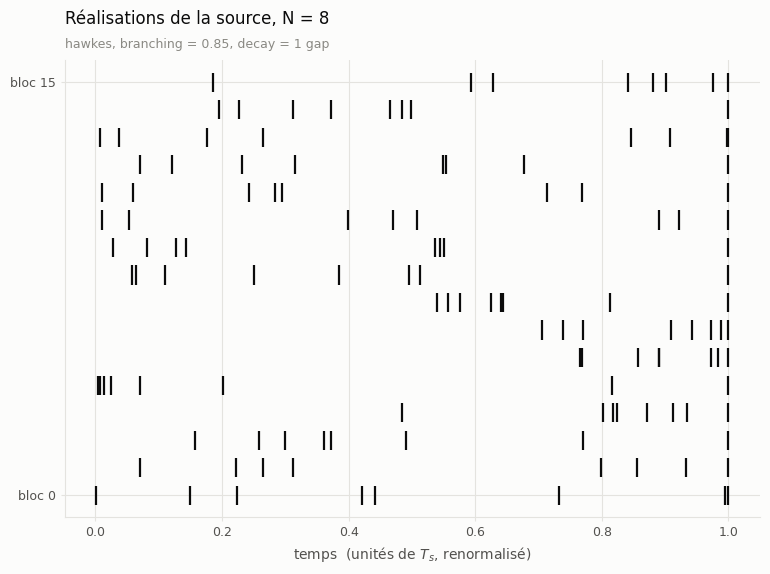

In [5]:
def fig_source_raster(cfg: Config, n_blocks: int = 16, seed: int = 3):
    t = sample_source(cfg, n_blocks, np.random.default_rng(seed)).numpy()
    fig, ax = plt.subplots(figsize=(7.8, 0.24 * n_blocks + 2.0), facecolor=SURFACE)
    ax.eventplot([row for row in t], colors=INK, lineoffsets=np.arange(n_blocks),
                 linelengths=0.7, linewidths=1.6, zorder=5)
    ax.set_ylim(-0.8, n_blocks - 0.2)
    ax.set_yticks([0, n_blocks - 1])
    ax.set_yticklabels(["bloc 0", f"bloc {n_blocks - 1}"])
    style(ax, "temps  (unités de $T_s$, renormalisé)", "",
          f"Réalisations de la source, N = {cfg.n_events}",
          f"hawkes, branching = {cfg.hawkes_branching:g}, decay = {cfg.hawkes_decay:g} gap")
    fig.tight_layout()
    return fig


for b in (0.0, 0.6, 0.85):
    fig_source_raster(replace(CFG, hawkes_branching=b), n_blocks=RASTER_N_BLOCKS,
                      seed=RASTER_SEED)
    plt.show()

## Canal

Jitter gaussien additif, identique à `point_process_jscc.ipynb` : `Y_i = X_i + Z_i`,
`Z_i ~ N(0, sigma_J^2)`, puis tri (le décodeur reçoit un ensemble de points, pas une séquence
étiquetée).

In [6]:
def channel(x: torch.Tensor, sigma: float, cfg: Config, gen: torch.Generator | None = None):
    z = torch.randn(x.shape, generator=gen, device=x.device) * sigma
    y = x + z
    if cfg.sort_output:
        y, perm = y.sort(dim=1)
    else:
        perm = torch.arange(x.shape[1], device=x.device).expand_as(x)
    return y, perm

## Le SNN simple

Un seul ingrédient spiking : la cellule LIF (leaky integrate-and-fire), seuil dur en avant
(Heaviside), surrogate gradient arctan en arrière (Neftci, Mostafa & Zenke) — la même recette
que `temporal-jscc/src/snn.py`. Les blocs sont traités événement par événement (l'axe "temps" du
réseau est l'indice d'événement, pas un bin physique) : c'est un choix délibéré plutôt qu'un
raster binné en `T` bins, pour rester fidèle aux équations du PDF, qui sont toutes en temps
continu (`T_i`, `X_i`, `Y_i` sont des réels, pas des indices de bin) — discrétiser introduirait un
`T` arbitraire et une quantification que l'énoncé ne demande pas.

**Volontairement simple** : une seule couche cachée, **feed-forward** (pas de poids récurrent
appris). La mémoire d'un événement à l'autre vient uniquement de la fuite du potentiel de
membrane (`u_t = beta * u_{t-1} * (1 - s_{t-1}) + I_t`) — vérifié que rajouter une connexion
récurrente entraînée n'apportait rien : le même bug de réordonnancement apparaissait avec ou sans
elle, donc elle n'était pas ce qui manquait. Le readout, lui, est un simple neurone linéaire
appliqué aux spikes de l'étape courante (pas un intégrateur qui persiste sur tout le bloc :
vérifié qu'un tel intégrateur fait dériver la sortie décodée à chaque événement suivant, la
mémoire utile étant déjà portée par la cellule LIF cachée).

In [7]:
class ATanSpike(torch.autograd.Function):
    """Heaviside en avant, surrogate arctan en arrière (Neftci, Mostafa & Zenke)."""

    @staticmethod
    def forward(ctx, u, alpha):
        ctx.save_for_backward(u)
        ctx.alpha = alpha
        return (u > 0).to(u.dtype)

    @staticmethod
    def backward(ctx, grad_out):
        (u,) = ctx.saved_tensors
        a = ctx.alpha
        return grad_out * a / (2 * (1 + (torch.pi / 2 * a * u) ** 2)), None


def spike(u, alpha: float = 2.0):
    return ATanSpike.apply(u, alpha)


class LIFCell(nn.Module):
    """u_t = beta * u_{t-1} * (1 - s_{t-1}) + I_t ; s_t = H(u_t - theta).

    beta (fuite) et theta (seuil) sont appris, par unité. Le facteur de reset
    est détaché (SuperSpike, 2e approximation) : c'est le seul endroit où vit
    un état, donc la seule mémoire d'un événement à l'autre.
    """

    def __init__(self, n_units: int, beta: float = 0.9, theta: float = 1.0, alpha: float = 2.0):
        super().__init__()
        self.alpha = alpha
        self.beta_logit = nn.Parameter(torch.logit(torch.full((n_units,), beta)))
        self.theta = nn.Parameter(torch.full((n_units,), theta))

    def forward(self, current, u, s):
        beta = torch.sigmoid(self.beta_logit)
        if u is None:
            u = torch.zeros_like(current)
            s = torch.zeros_like(current)
        u = beta * u * (1.0 - s.detach()) + current
        s = spike(u - self.theta, self.alpha)
        return s, u, s


class SimpleSNN(nn.Module):
    """Toute l'architecture, encodeur et décodeur partagent cette classe : une
    synapse linéaire vers une couche LIF, déroulée sur les N événements du
    bloc (dans l'ordre temporel), puis un readout linéaire à chaque pas. Rien
    de plus -- pas de couche supplémentaire, pas de récurrence apprise.
    """

    def __init__(self, cfg: Config, n_in: int = 2, beta: float = 0.9):
        super().__init__()
        self.cfg = cfg
        self.in_norm = nn.LayerNorm(n_in)
        self.syn = nn.Linear(n_in, cfg.hidden, bias=False)
        self.lif = LIFCell(cfg.hidden, beta=beta)
        self.head = nn.Linear(cfg.hidden, 1)
        nn.init.zeros_(self.head.weight)
        nn.init.zeros_(self.head.bias)   # démarre sur la sortie neutre (raw = 0)

    def forward(self, feats: torch.Tensor) -> torch.Tensor:
        """feats: (B, N, n_in) -> (B, N), un réel par événement."""
        u, s = None, None
        outs = []
        for i in range(feats.shape[1]):
            current = self.syn(self.in_norm(feats[:, i]))
            s, u, _ = self.lif(current, u, s)
            outs.append(self.head(s).squeeze(-1))
        return torch.stack(outs, dim=1)


def event_features(t: torch.Tensor, cfg: Config) -> torch.Tensor:
    """(B,N) temps -> (B,N,2) : [temps/Ts, gap/gap moyen] par événement."""
    s = (t / cfg.Ts).unsqueeze(-1)
    g = torch.diff(t, dim=1, prepend=torch.zeros_like(t[:, :1])) / cfg.mean_gap
    return torch.cat([s, g.unsqueeze(-1)], dim=-1)


def gaps(t: torch.Tensor) -> torch.Tensor:
    return torch.diff(t, dim=1, prepend=torch.zeros_like(t[:, :1]))

In [8]:
class Encoder(nn.Module):
    """Facteur multiplicatif positif par écart -- ordre préservé par
    construction (cf. l'intro : la version "déplacement additif" inverse
    15-35% des paires d'événements dès le début de l'entraînement, avec le
    SNN comme avec le MLP original)."""

    def __init__(self, cfg: Config):
        super().__init__()
        self.cfg = cfg
        self.net = SimpleSNN(cfg)

    def forward(self, t: torch.Tensor):
        cfg = self.cfg
        raw = self.net(event_features(t, cfg))
        mult = torch.exp(cfg.log_max_stretch * torch.tanh(raw))
        x = torch.cumsum(gaps(t) * mult, dim=1)
        delta = x - t
        if cfg.window == "clamp":
            x = x.clamp(0.0, cfg.Tc)
        return x, delta


class Decoder(nn.Module):
    def __init__(self, cfg: Config):
        super().__init__()
        self.cfg = cfg
        self.net = SimpleSNN(cfg)

    def forward(self, y: torch.Tensor) -> torch.Tensor:
        cfg = self.cfg
        raw = self.net(event_features(y, cfg))
        return y + cfg.mean_gap * cfg.max_corr * torch.tanh(raw)


class System(nn.Module):
    """mode: "uncoded" (sans paramètre) | "decoder" | "jscc"."""

    MODES = ("uncoded", "decoder", "jscc")

    def __init__(self, cfg: Config, mode: str):
        super().__init__()
        assert mode in self.MODES
        self.cfg, self.mode = cfg, mode
        self.encoder = Encoder(cfg) if mode == "jscc" else None
        self.decoder = Decoder(cfg) if mode in ("decoder", "jscc") else None

    def forward(self, t, sigma=None, gen=None):
        sigma = self.cfg.sigma_J if sigma is None else sigma
        if self.encoder is None:
            x, delta = t, torch.zeros_like(t)
        else:
            x, delta = self.encoder(t)
        y, perm = channel(x, sigma, self.cfg, gen)
        s_hat = y if self.decoder is None else self.decoder(y)
        return {"s_hat": s_hat, "x": x, "y": y, "delta": delta, "perm": perm}

    @property
    def n_params(self) -> int:
        return sum(p.numel() for p in self.parameters())

## Entraînement et mesure

In [9]:
def reorder_frac(x: torch.Tensor) -> float:
    """Fraction des paires d'événements dont l'ordre a changé entre t (déjà
    trié) et x -- doit rester à 0 avec l'encodeur multiplicatif."""
    _, perm = x.sort(dim=1)
    idx = torch.arange(x.shape[1]).expand_as(perm)
    return float((perm != idx).float().mean())


def train_system(cfg: Config, mode: str, verbose: bool = False):
    torch.manual_seed(cfg.seed)
    rng = np.random.default_rng(cfg.seed)
    gen = torch.Generator(device=DEVICE).manual_seed(cfg.seed + 1)
    model = System(cfg, mode).to(DEVICE)
    history = []
    if model.n_params == 0:
        return model, history

    opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr)
    sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=cfg.lr,
                                                total_steps=cfg.steps, pct_start=0.1)
    t0 = time.time()
    for step in range(1, cfg.steps + 1):
        t = sample_source(cfg, cfg.batch, rng)
        out = model(t, gen=gen)
        loss = F.mse_loss(out["s_hat"], t)
        opt.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        opt.step()
        sched.step()
        if step % max(1, cfg.steps // 6) == 0 or step == cfg.steps:
            history.append({"step": step, "loss": float(loss.detach())})
            if verbose:
                print(f"  {mode:8s} step {step:5d}  loss {float(loss.detach()):.3e}"
                      f"  reorder {reorder_frac(out['x']):.3f}"
                      f"  {time.time() - t0:.0f}s", flush=True)
    return model, history


@torch.no_grad()
def measure(model: System, cfg: Config, seed: int = 99991) -> dict:
    rng = np.random.default_rng(seed)
    gen = torch.Generator(device=DEVICE).manual_seed(seed)
    model.eval()
    t = sample_source(cfg, cfg.eval_batch, rng)
    out = model(t, sigma=cfg.sigma_J, gen=gen)
    err = (out["s_hat"] - t) ** 2
    block_mse = err.mean(dim=1)
    model.train()
    return {"d_mse": float(err.mean()), "median_block_mse": float(block_mse.median()),
            "p99_block_mse": float(block_mse.quantile(0.99)),
            "reorder_frac": reorder_frac(out["x"]),
            "frac_beyond_Ts": float((t[:, -1] > cfg.Ts + 1e-4).float().mean()),
            "sigma_J": cfg.sigma_J, "hawkes_branching": cfg.hawkes_branching,
            "mode": model.mode, "n_params": model.n_params}

## Sweep — l'intensité des rafales change-t-elle le gain JSCC ?

Question centrale du PDF (section "Step 2", adaptée à Hawkes plutôt qu'au renouvellement Gamma
qu'il propose) : plus les événements sont groupés en rafales (branching élevé), plus il devrait y
avoir de structure à exploiter pour l'encodeur -- *si* le système apprend effectivement quelque
chose au-delà de la source memoryless (`branching = 0`, quasi-Poisson).

`sigma_J` est fixé pour tout le sweep, de sorte que toute différence entre les trois systèmes à
un `branching` donné vienne de la source, pas du canal.

In [10]:
def run_sweep(branching_grid=BRANCHING_GRID, sigma_ratio=SIGMA_RATIO, modes=MODES, verbose=True):
    rows, models = [], {}
    for b in branching_grid:
        cfg = replace(CFG, hawkes_branching=b, sigma_J=sigma_ratio * CFG.mean_gap)
        for mode in modes:
            t0 = time.time()
            model, hist = train_system(cfg, mode)
            m = measure(model, cfg)
            m["train_seconds"] = time.time() - t0
            rows.append(m)
            models[(b, mode)] = (model, cfg, hist)
            if verbose:
                print(f"branching {b:4.2f}  {mode:8s}  d_mse {m['d_mse']:.3e}"
                      f"  reorder {m['reorder_frac']:.3f}"
                      f"  ({m['train_seconds']:.0f}s)", flush=True)
    return rows, models


HAWKES_ROWS, HAWKES_MODELS = run_sweep()

branching 0.00  uncoded   d_mse 1.639e-03  reorder 0.000  (1s)


branching 0.00  decoder   d_mse 1.574e-03  reorder 0.000  (62s)


branching 0.00  jscc      d_mse 1.557e-03  reorder 0.000  (67s)


branching 0.30  uncoded   d_mse 1.616e-03  reorder 0.000  (1s)


branching 0.30  decoder   d_mse 1.561e-03  reorder 0.000  (61s)


...

branching 0.60  decoder   d_mse 1.518e-03  reorder 0.000  (60s)


branching 0.60  jscc      d_mse 1.497e-03  reorder 0.000  (64s)


branching 0.85  uncoded   d_mse 1.567e-03  reorder 0.000  (1s)


branching 0.85  decoder   d_mse 1.500e-03  reorder 0.000  (60s)


branching 0.85  jscc      d_mse 1.517e-03  reorder 0.000  (64s)


In [11]:
def show_table(rows, cols=None, title=""):
    cols = cols or ["hawkes_branching", "mode", "d_mse", "median_block_mse",
                    "p99_block_mse", "reorder_frac", "n_params"]
    w = {c: max(len(c), 11) for c in cols}
    if title:
        print(title)
    print(" | ".join(c.rjust(w[c]) for c in cols))
    print("-+-".join("-" * w[c] for c in cols))
    for r in rows:
        cells_ = []
        for c in cols:
            v = r.get(c, "")
            if isinstance(v, float):
                v = f"{v:.4e}" if (v != 0 and abs(v) < 1e-3) else f"{v:.4f}"
            cells_.append(str(v).rjust(w[c]))
        print(" | ".join(cells_))


show_table(HAWKES_ROWS, title=f"Hawkes, N={CFG.n_events}, sigma_J/gap = {SIGMA_RATIO:g}")

Hawkes, N=8, sigma_J/gap = 0.4
hawkes_branching |        mode |       d_mse | median_block_mse | p99_block_mse | reorder_frac |    n_params
-----------------+-------------+-------------+------------------+---------------+--------------+------------
          0.0000 |     uncoded |      0.0016 |           0.0015 |        0.0043 |       0.0000 |           0
          0.0000 |     decoder |      0.0016 |           0.0014 |        0.0041 |       0.0000 |         325
          0.0000 |        jscc |      0.0016 |           0.0014 |        0.0040 |       0.0000 |         650
          0.3000 |     uncoded |      0.0016 |           0.0015 |        0.0043 |       0.0000 |           0
          0.3000 |     decoder |      0.0016 |           0.0014 |        0.0041 |       0.0000 |         325
          0.3000 |        jscc |      0.0015 |           0.0014 |        0.0040 |       0.0000 |         650
          0.6000 |     uncoded |      0.0016 |           0.0014 |        0.0042 |       0.0000 | 

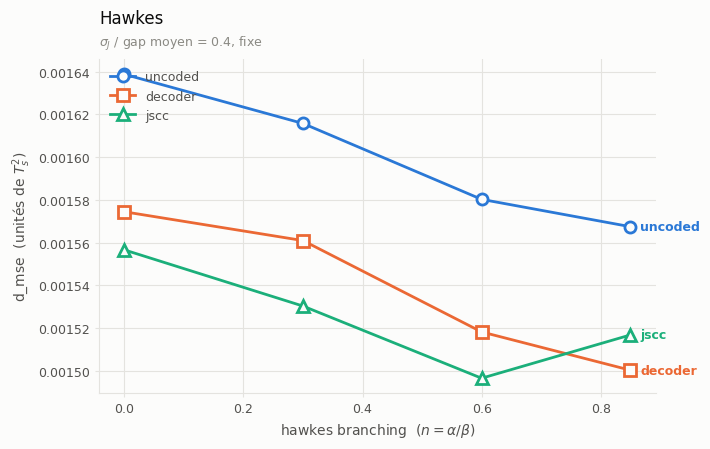

In [12]:
def fig_distortion(rows, metric="d_mse", title="Hawkes"):
    fig, ax = plt.subplots(figsize=(7.2, 4.6), facecolor=SURFACE)
    for mode in MODES:
        pts = sorted([r for r in rows if r["mode"] == mode],
                     key=lambda r: r["hawkes_branching"])
        if not pts:
            continue
        colour, marker = MODE_STYLE[mode]
        xs = [r["hawkes_branching"] for r in pts]
        ys = [r[metric] for r in pts]
        ax.plot(xs, ys, color=colour, lw=2.0, marker=marker, ms=8, mew=2.0,
                mfc=SURFACE, mec=colour, zorder=5, label=mode)
        ax.annotate(mode, (xs[-1], ys[-1]), textcoords="offset points",
                    xytext=(7, 0), color=colour, fontsize=9, fontweight="bold",
                    va="center")
    unit = "$T_s^2$"
    style(ax, "hawkes branching  ($n = \\alpha/\\beta$)", f"{metric}  (unités de {unit})",
          title, f"$\\sigma_J$ / gap moyen = {SIGMA_RATIO:g}, fixe")
    legend(ax)
    fig.tight_layout()
    return fig


fig_distortion(HAWKES_ROWS)
plt.show()

## Le mapping des écarts (éq. 12) — qu'apprend l'encodeur ?

Pour chaque `branching`, on trace `g_i` (l'écart source) contre `g_i^{(X)}` (l'écart après
encodage). Si l'encodeur avait convergé vers l'identité (remarque du PDF pour Poisson : le cas le
plus probable quand la source n'a pas de structure), tous les points seraient sur la diagonale.
On regarde aussi le facteur multiplicatif lui-même en fonction de la taille de l'écart source,
pour voir si les petits écarts (intra-rafale) et les grands écarts (silences) sont traités
différemment.

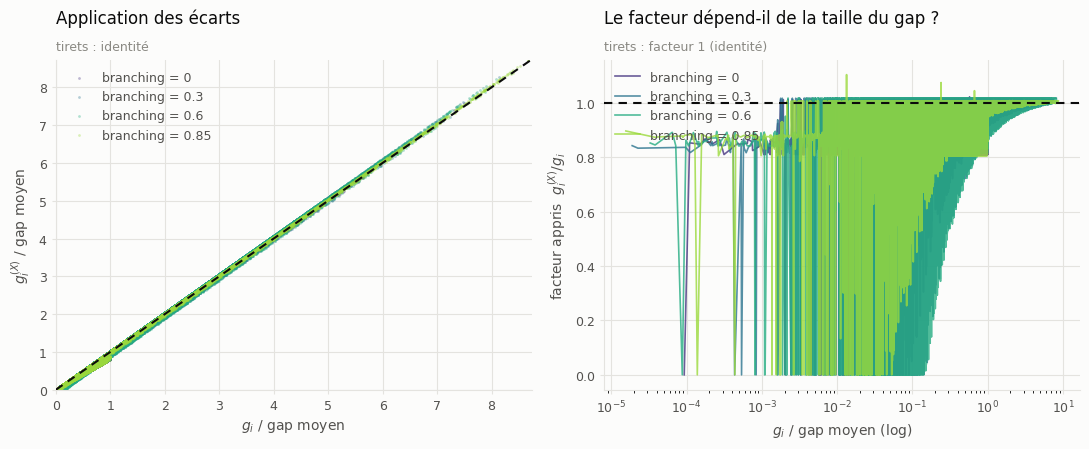

In [13]:
def fig_gap_mapping(models, branchings, n_blocks=GAPMAP_N_BLOCKS, seed=GAPMAP_SEED):
    fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.6), facecolor=SURFACE)
    colours = plt.get_cmap("viridis")(np.linspace(0.15, 0.85, len(branchings)))
    lim = 0.0
    for colour, b in zip(colours, branchings):
        model, cfg, _ = models[(b, "jscc")]
        rng = np.random.default_rng(seed)
        with torch.no_grad():
            t = sample_source(cfg, n_blocks, rng)
            x, _ = model.encoder(t)
        gs = gaps(t).numpy().ravel() / cfg.mean_gap
        gx = gaps(x).numpy().ravel() / cfg.mean_gap
        lim = max(lim, gs.max(), gx.max())
        axes[0].scatter(gs, gx, s=4, color=colour, alpha=0.35, lw=0,
                        label=f"branching = {b:g}")
        mult = gx / np.clip(gs, 1e-6, None)
        order = np.argsort(gs)
        axes[1].plot(gs[order], mult[order], color=colour, lw=1.2, alpha=0.8,
                     label=f"branching = {b:g}")

    axes[0].plot([0, lim], [0, lim], color=INK, lw=1.5, ls=(0, (4, 3)), zorder=4)
    axes[0].set_xlim(0, lim); axes[0].set_ylim(0, lim)
    style(axes[0], "$g_i$ / gap moyen", "$g_i^{(X)}$ / gap moyen",
          "Application des écarts", "tirets : identité")
    legend(axes[0])

    axes[1].axhline(1.0, color=INK, lw=1.5, ls=(0, (4, 3)), zorder=4)
    axes[1].set_xscale("log")
    style(axes[1], "$g_i$ / gap moyen (log)", "facteur appris  $g_i^{(X)} / g_i$",
          "Le facteur dépend-il de la taille du gap ?", "tirets : facteur 1 (identité)")
    legend(axes[1])
    fig.tight_layout()
    return fig


fig_gap_mapping(HAWKES_MODELS, [0.0, 0.3, 0.6, 0.85])
plt.show()

## Une réalisation à travers la chaîne

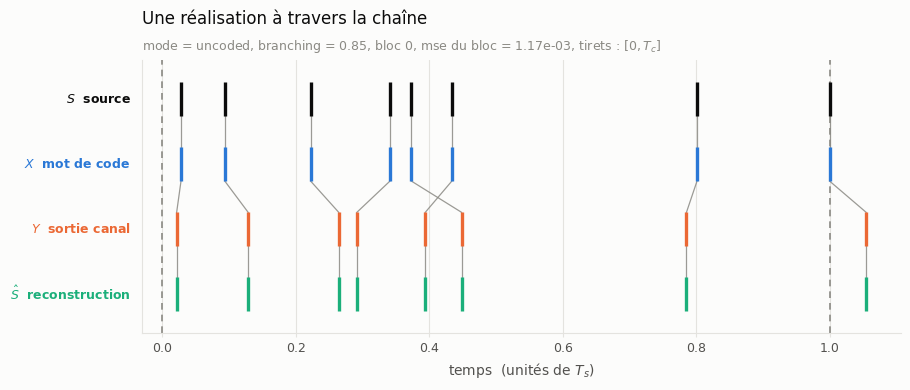

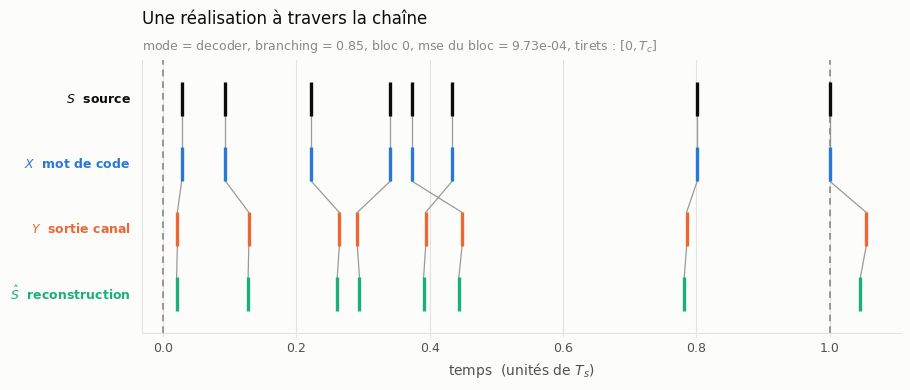

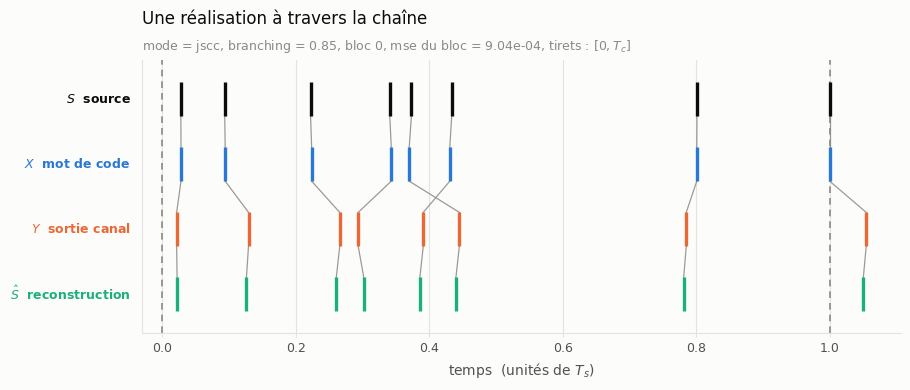

In [14]:
def fig_realisation(models, b, mode="jscc", block=REALISATION_BLOCK, seed=REALISATION_SEED):
    model, cfg, _ = models[(b, mode)]
    rng = np.random.default_rng(seed)
    gen = torch.Generator(device=DEVICE).manual_seed(seed)
    with torch.no_grad():
        t = sample_source(cfg, block + 1, rng)
        o = model(t, gen=gen)
    S, X = t[block].numpy(), o["x"][block].numpy()
    Y, H = o["y"][block].numpy(), o["s_hat"][block].numpy()
    perm = o["perm"][block].numpy()

    rows = [("$S$  source", S, INK), ("$X$  mot de code", X, C_UNCODED),
            ("$Y$  sortie canal", Y, C_DECODER), ("$\\hat{S}$  reconstruction", H, C_JSCC)]
    fig, ax = plt.subplots(figsize=(9.2, 4.0), facecolor=SURFACE)
    for k, (name, vals, colour) in enumerate(rows):
        y0 = len(rows) - 1 - k
        ax.eventplot([vals], colors=colour, lineoffsets=y0, linelengths=0.52,
                     linewidths=2.4, zorder=6)
        ax.text(-0.015, y0, name, transform=ax.get_yaxis_transform(), color=colour,
                fontsize=9, fontweight="bold", ha="right", va="center")
    for i in range(len(S)):
        ax.plot([S[i], X[i]], [3 - 0.26, 2 + 0.26], color=MUTED, lw=0.9, alpha=0.85, zorder=3)
    for j in range(len(Y)):
        ax.plot([X[perm[j]], Y[j]], [2 - 0.26, 1 + 0.26], color=MUTED, lw=0.9, alpha=0.85, zorder=3)
        ax.plot([Y[j], H[j]], [1 - 0.26, 0 + 0.26], color=MUTED, lw=0.9, alpha=0.85, zorder=3)
    for xv in (0.0, cfg.Tc):
        ax.axvline(xv, color=MUTED, lw=1.2, ls=(0, (4, 3)), zorder=2)
    err = float(((H - S) ** 2).mean())
    sub = (f"mode = {mode}, branching = {b:g}, bloc {block}, "
           f"mse du bloc = {err:.2e}, tirets : $[0, T_c]$")
    ax.set_ylim(-0.6, 3.6); ax.set_yticks([])
    style(ax, "temps  (unités de $T_s$)", "", "Une réalisation à travers la chaîne", sub)
    fig.tight_layout()
    return fig


for m in MODES:
    fig_realisation(HAWKES_MODELS, 0.85, mode=m)
    plt.show()

## Limites et choix à assumer

- **Un seul seed par point** du sweep : les écarts entre `decoder` et `jscc` (quelques % selon les
  résultats ci-dessus) sont à lire avec cette réserve — pas de barre d'erreur ici.
- **Budget d'entraînement** modeste (`steps = 3000`, réseau à 64 unités cachées). `temporal-jscc`
  documente en détail (voir son README) que ce genre de système peut sembler ne rien apprendre
  simplement parce que l'optimiseur n'a pas eu le temps de converger -- si les gains JSCC
  semblent plats ici, augmenter `steps` et/ou `lr` avant de conclure que la structure n'est pas
  exploitable.
- **`sigma_J` fixe** pour tout le sweep en branching : un sweep croisé (branching x sigma) donnerait
  une vue plus complète, mais multiplie le coût par la taille de la seconde grille.
- Le SNN reste volontairement **à une seule couche cachée feed-forward** -- un choix de simplicité,
  pas une limite de capacité démontrée : rien n'empêche d'empiler une seconde couche `SimpleSNN`
  si le gain JSCC observé donne envie de pousser plus loin.